## Daftar Isi Notebook

*   **Unggah dan Ekstrak Dataset**: Mengunggah file zip dataset dan mengekstrak isinya ke direktori lokal.
*   **Inisialisasi dan Persiapan Data**: Mengimpor pustaka yang diperlukan dan mendefinisikan informasi metadata untuk berbagai jenis sampah.
*   **Pengumpulan Data Gambar dan Metadata**: Membaca setiap gambar dari dataset, mengekstrak properti gambar (lebar, tinggi, format, ukuran file), dan menggabungkannya dengan informasi dampak serta penanganan sampah yang telah didefinisikan.
*   **Pembuatan dan Eksplorasi DataFrame**: Mengonversi data yang terkumpul menjadi DataFrame pandas, menampilkan beberapa baris pertama, dan memeriksa dimensinya.
*   **Penyimpanan dan Unduh Dataset**: Menyimpan DataFrame ke file CSV dan menyediakannya untuk diunduh.
*   **Analisis Distribusi Dataset**: Menghitung jumlah setiap kelas sampah dan memvisualisasikan distribusinya dalam bentuk grafik batang.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ds_new.zip to ds_new.zip


In [ ]:
import zipfile
import os

zip_path = "ds_new.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


In [ ]:
import pandas as pd
from PIL import Image

In [ ]:
base_path = "/content/dataset/ds_new"

os.listdir(base_path)

['organik',
 'B3',
 'Medis',
 'Plastik',
 'Kaca',
 'nonsampah',
 'Kardus',
 'Logam',
 'Kertas']

In [ ]:
informasi_sampah = {

    "Plastik": {
        "dampak": "Sulit terurai dan mencemari lingkungan",
        "penanganan": "Didaur ulang menjadi kerajinan"
    },

    "Kaca": {
        "dampak": "Berbahaya jika pecah",
        "penanganan": "Didaur ulang di bank sampah"
    },

    "Kertas": {
        "dampak": "Menyebabkan penebangan pohon",
        "penanganan": "Didaur ulang menjadi kertas baru"
    },

    "Kardus": {
        "dampak": "Menumpuk menjadi limbah",
        "penanganan": "Didaur ulang"
    },

    "Logam": {
        "dampak": "Dapat mencemari tanah",
        "penanganan": "Didaur ulang di industri logam"
    },

    "organik": {
        "dampak": "Menghasilkan bau jika menumpuk",
        "penanganan": "Diolah menjadi kompos"
    },

    "B3": {
        "dampak": "Beracun dan berbahaya",
        "penanganan": "Dibuang ke TPS khusus"
    },

    "Medis": {
        "dampak": "Menyebarkan penyakit",
        "penanganan": "Sterilisasi dan pemusnahan"
    },

    "nonsampah": {
        "dampak": "Bukan kategori sampah",
        "penanganan": "Tidak memerlukan pengolahan"
    }
}

In [ ]:
data = []

gambar_gagal = 0

for kelas in os.listdir(base_path):

    kelas_path = os.path.join(base_path, kelas)

    if os.path.isdir(kelas_path):

        for file in os.listdir(kelas_path):

            file_path = os.path.join(kelas_path, file)

            try:

                # buka gambar
                img = Image.open(file_path)

                # ukuran gambar
                width, height = img.size

                # format gambar
                img_format = img.format

                # ukuran file KB
                file_size = os.path.getsize(file_path) / 1024

                # metadata tambahan
                dampak = informasi_sampah[kelas]["dampak"]
                penanganan = informasi_sampah[kelas]["penanganan"]

                # simpan data
                data.append({
                    "filename": file,
                    "kelas": kelas,
                    "width": width,
                    "height": height,
                    "file_size_kb": round(file_size, 2),
                    "format": img_format,
                    "source": "Manual Collection",
                    "data_split": "Train",
                    "dampak": dampak,
                    "penanganan": penanganan
                })

            except Exception as e:

                gambar_gagal += 1

                print(f"Gagal membaca: {file}")

In [ ]:
print("Total gambar gagal:", gambar_gagal)

Total gambar gagal: 0


In [ ]:
df = pd.DataFrame(data)

In [ ]:
df.head()

,filename,kelas,width,height,file_size_kb,format,source,data_split,dampak,penanganan
0,O_13587 - Copy.jpg,organik,224,224,15.95,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos
1,Food Organics_359.jpg,organik,224,224,13.86,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos
2,Food Organics_343.jpg,organik,224,224,12.57,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos
3,O_13639 - Copy - Copy.jpg,organik,224,224,9.75,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos
4,Food Organics_187.jpg,organik,224,224,13.16,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos


In [ ]:
df.shape

(19185, 10)

In [ ]:
df.to_csv("dataset_tab.csv", index=False)

print("CSV berhasil dibuat!")

CSV berhasil dibuat!


In [ ]:
files.download("dataset_tab.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df['kelas'].value_counts()

,count
kelas,
nonsampah,9200
Kertas,1806
organik,1364
Plastik,1257
Medis,1227
Logam,1210
Kaca,1108
Kardus,1013
B3,1000


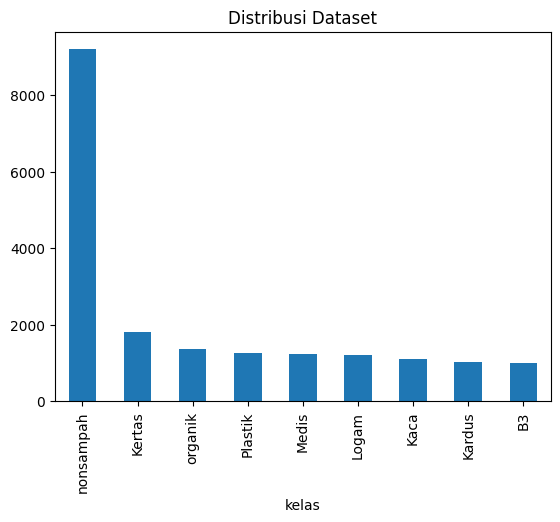

In [ ]:
import matplotlib.pyplot as plt

df['kelas'].value_counts().plot(kind='bar')

plt.title("Distribusi Dataset")
plt.show()